## Initial baseline model

In [39]:
# Imports
import random
import os
import json
import re
from pathlib import Path
import tqdm
import cv2
from scipy import ndimage


import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

from scripts.preprocess import *
from scripts.pt_model import *
from scripts.layoutlmv3_model import *
from scripts.basic_model import *

from scripts.visualize_util import create_analysis_dashboard, visualize_sample_results

In [40]:
ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")
print(ground_truth_df.columns)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth'],
      dtype='str')


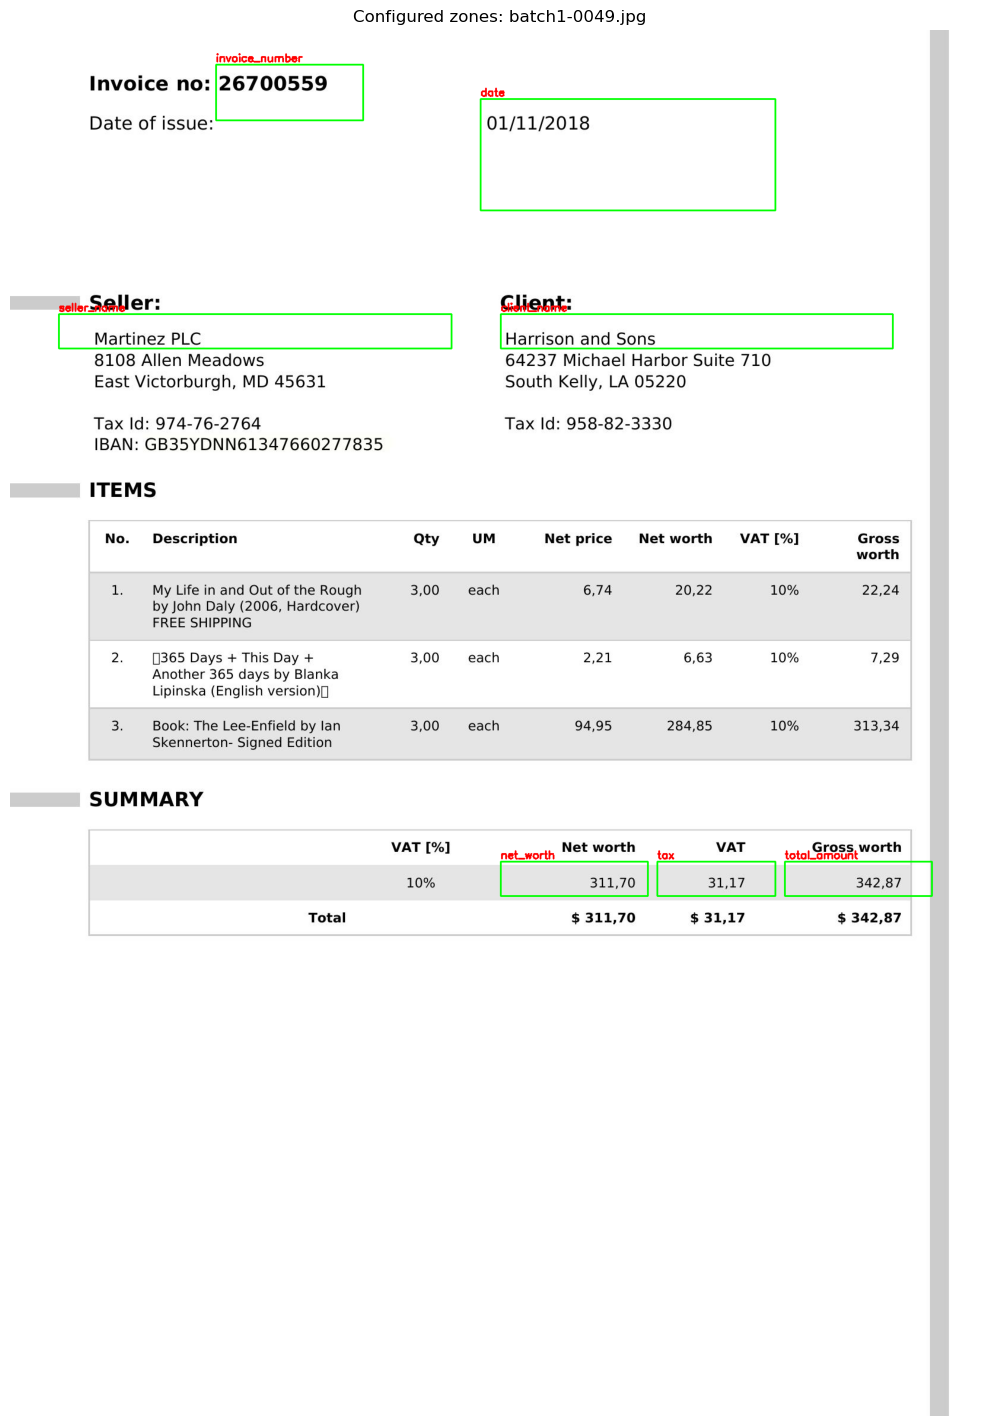

{'invoice_number': '26700559', 'date': '01/11/2018', 'invoice_date': '01/11/2018', 'seller_name': 'Martinez PLC', 'client_name': 'Harrison and Sons', 'net_worth': '311.70', 'tax': '31.17', 'total_amount': '342.87'}
{'invoice_number': '26700559', 'date': '01/11/2018', 'seller_name': 'Martinez PLC', 'client_name': 'Harrison and Sons', 'net_worth': '311,70', 'tax': '31,17', 'total_amount': '342,87'}


In [53]:
zones = {
        "default": {
        # Top-left: Invoice number
        "invoice_number": (0.21, 0.025, 0.15, 0.04),

        # Slightly below, shifted right: Date
        "date": (0.48, 0.05, 0.30, 0.08),

        # Middle section
        "seller_name": (0.05, 0.205, 0.40, 0.025),   # Seller block
        "client_name": (0.50, 0.205, 0.40, 0.025),   # Client block

        # Bottom-right summary section
        "net_worth": (0.50, 0.60, 0.15, 0.025),      # Net worth
        "tax": (0.66, 0.60, 0.12, 0.025),           # VAT
        "total_amount": (0.79, 0.60, 0.15, 0.025),  # Gross worth
        }
        }

# 1) Create the pipeline
basic_pipeline = InvoiceZonalOCRPipeline(template_zones=zones,
    output_dir="../finalproject_data/output_images/basic_ocr"
)

# 2) Tune zones visually on one representative invoice
sample_image = "../finalproject_data/batch_1/batch1_1/batch1-0049.jpg"
basic_pipeline.visualize_zones(sample_image, template_name="default")

# 3) Process one invoice
result = basic_pipeline.process_invoice(sample_image, template_name="default")
print(result["fields"])
print(result["zone_text"])


In [54]:
# 4) Batch process a folder of invoice images
# Define the subfolders you want to process
subfolders = ["batch1_1", "batch1_2", "batch1_3"]
base_path = "../finalproject_data/batch_1/"

# Process each folder and store the resulting dataframes in a list
all_preds = [
    basic_pipeline.process_folder(f"{base_path}{folder}", template_name="default", sample_frac=0.2) 
    for folder in subfolders
]

# Concatenate all dataframes into one
pred_df = pd.concat(all_preds, ignore_index=True)
print(pred_df.head())

Processing 99 images...


Processing invoices: 100%|██████████| 99/99 [02:21<00:00,  1.43s/it]


Processing 100 images...


Processing invoices: 100%|██████████| 100/100 [02:49<00:00,  1.70s/it]


Processing 97 images...


Processing invoices: 100%|██████████| 97/97 [02:22<00:00,  1.47s/it]

         File Name                                         image_path  \
0  batch1-0328.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
1  batch1-0058.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
2  batch1-0013.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
3  batch1-0380.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
4  batch1-0141.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   

   success invoice_number        date invoice_date              seller_name  \
0     True       14165207  02/13/2014   02/13/2014               Patel-Park   
1     True       80489404  12/21/2013   12/21/2013             Gonzalez LLC   
2     True       57986024  10/17/2015   10/17/2015              Schmidt LLC   
3     True       13310164  01/16/2020   01/16/2020           Montgomery LLC   
4     True       73783721  10/22/2011   10/22/2011  Wood, Nichols and Perry   

                  client_name net_worth       tax total_amount  
0  Adkins, Hodges and

In [55]:
metrics_df = basic_pipeline.evaluate_against_ground_truth(pred_df, ground_truth_df)

         field  accuracy  precision   recall       f1  support
   client_name  0.996390   0.996390 0.996390 0.996390      277
   seller_name  0.996390   0.996390 0.996390 0.996390      277
invoice_number  1.000000   1.000000 1.000000 1.000000      277
  invoice_date  1.000000   1.000000 1.000000 1.000000      277
           tax  0.119134   0.270492 0.119134 0.165414      277
  total_amount  0.111913   0.254098 0.111913 0.155388      277
     net_worth  0.115523   0.258065 0.115523 0.159601      277


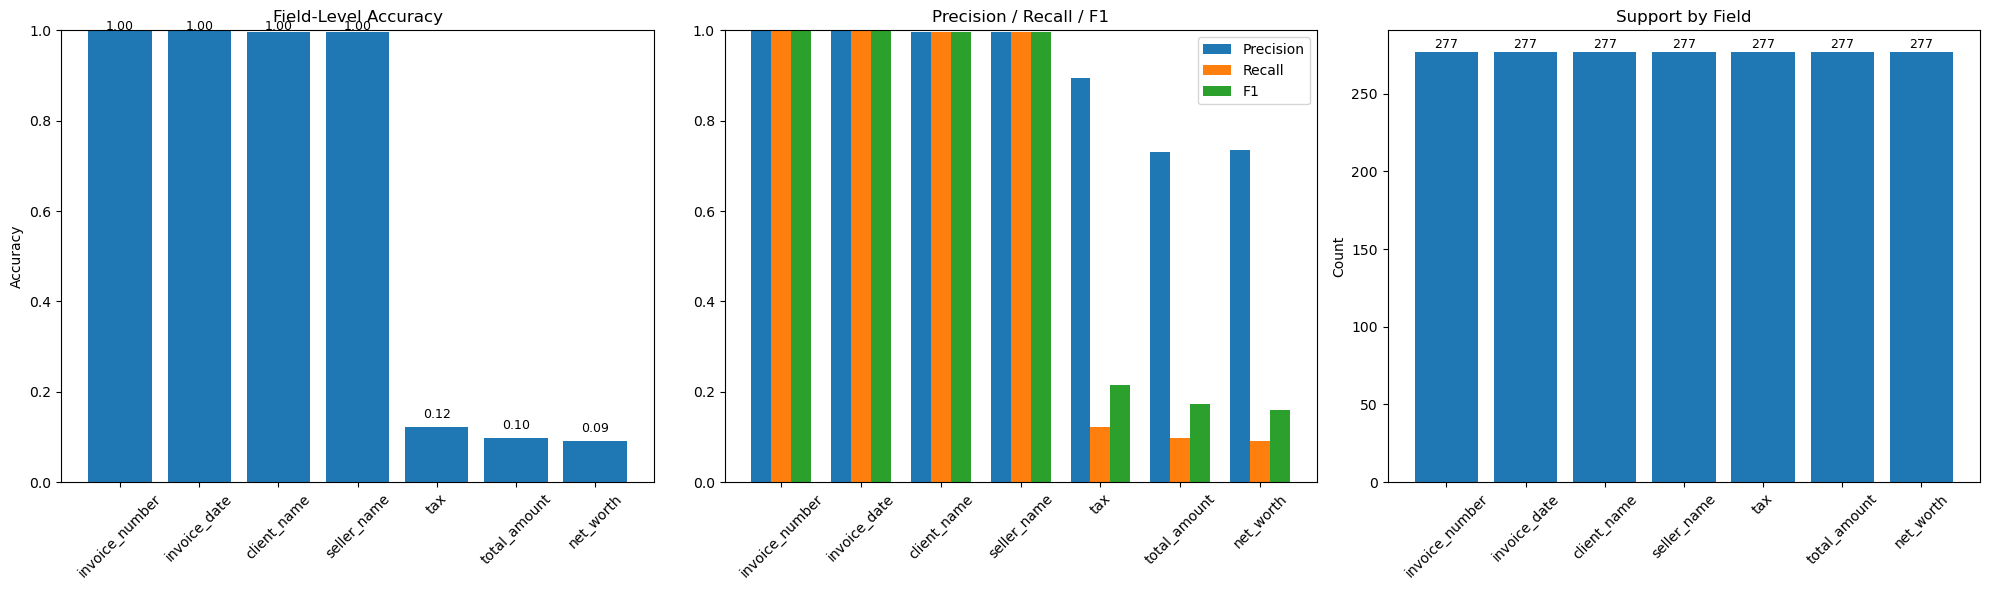

In [47]:
basic_pipeline.visualize_evaluation_metrics(metrics_df)

In [48]:
# Debug numeric parsing for basic model (20 sampled invoices)
# Shows raw OCR zone text vs parsed value vs GT for: tax, total_amount, net_worth.

from scripts.basic_model import clean_amount

if "pred_df" not in globals() or pred_df is None or len(pred_df) == 0:
    raise ValueError("Run the basic model inference cell first so `pred_df` exists.")
if "ground_truth_df" not in globals() or ground_truth_df is None or len(ground_truth_df) == 0:
    raise ValueError("Run the ground-truth loading cell first so `ground_truth_df` exists.")

fields = ["tax", "total_amount", "net_worth"]
sample_n = min(20, len(pred_df))
sample_df = pred_df.sample(n=sample_n, random_state=42).copy()
gt_cols = ["File Name"] + [f for f in fields if f in ground_truth_df.columns]
sample_df = sample_df.merge(ground_truth_df[gt_cols], on="File Name", how="left", suffixes=("", "_gt"))

rows = []
for _, r in sample_df.iterrows():
    img_path = r.get("image_path")
    if not isinstance(img_path, str) or not img_path:
        continue

    inv = basic_pipeline.process_invoice(img_path, template_name="default")
    zone_text = inv.get("zone_text", {}) or {}

    for field in fields:
        raw_text = zone_text.get(field)
        parsed_from_raw = clean_amount(raw_text)
        rows.append({
            "File Name": r.get("File Name"),
            "field": field,
            "raw_zone_text": raw_text,
            "parsed_from_raw": parsed_from_raw,
            "pred_df_value": r.get(field),
            "gt_value": r.get(field + "_gt"),
        })

numeric_debug_df = pd.DataFrame(rows)

for c in ["parsed_from_raw", "pred_df_value", "gt_value"]:
    numeric_debug_df[c + "_num"] = pd.to_numeric(numeric_debug_df[c], errors="coerce").round(2)

numeric_debug_df["parsed_matches_gt"] = (
    numeric_debug_df["parsed_from_raw_num"] == numeric_debug_df["gt_value_num"]
)
numeric_debug_df["pred_matches_gt"] = (
    numeric_debug_df["pred_df_value_num"] == numeric_debug_df["gt_value_num"]
)

print(f"Sampled invoices: {sample_n}")
print(f"Rows in debug table: {len(numeric_debug_df)}")
display(numeric_debug_df[[
    "File Name", "field", "raw_zone_text", "parsed_from_raw", "pred_df_value", "gt_value",
    "parsed_matches_gt", "pred_matches_gt"
]])

print("\nMatch rates by field")
display(
    numeric_debug_df.groupby("field")[["parsed_matches_gt", "pred_matches_gt"]]
    .mean()
    .rename(columns={"parsed_matches_gt": "parsed_match_rate", "pred_matches_gt": "pred_match_rate"})
)


Sampled invoices: 20
Rows in debug table: 60


,File Name,field,raw_zone_text,parsed_from_raw,pred_df_value,gt_value,parsed_matches_gt,pred_matches_gt
0,batch1-1036.jpg,tax,,NaN,NaN,339.09,False,False
1,batch1-1036.jpg,total_amount,4,NaN,NaN,3729.94,False,False
2,batch1-1036.jpg,net_worth,. .,NaN,NaN,3390.85,False,False
3,batch1-0676.jpg,tax,,NaN,NaN,10.19,False,False
4,batch1-0676.jpg,total_amount,,NaN,NaN,112.12,False,False
5,batch1-0676.jpg,net_worth,,NaN,NaN,101.93,False,False
6,batch1-0052.jpg,tax,,NaN,NaN,22.16,False,False
7,batch1-0052.jpg,total_amount,,NaN,NaN,243.71,False,False
8,batch1-0052.jpg,net_worth,,NaN,NaN,221.55,False,False
9,batch1-0433.jpg,tax,,NaN,NaN,27.89,False,False



Match rates by field


,parsed_match_rate,pred_match_rate
field,,
net_worth,0.05,0.05
tax,0.05,0.05
total_amount,0.05,0.05


## CV Model


Processing: batch1_1.csv
Processing 499 images from ../finalproject_data/batch_1/batch1_1.csv
Images location: ../finalproject_data/batch_1/batch1_1


Processing batches: 100%|██████████| 10/10 [00:44<00:00,  4.50s/it]



Processing Complete!
Total images processed: 499
Successful: 499
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_2.csv
Processing 426 images from ../finalproject_data/batch_1/batch1_2.csv
Images location: ../finalproject_data/batch_1/batch1_2


Processing batches: 100%|██████████| 9/9 [00:38<00:00,  4.27s/it]



Processing Complete!
Total images processed: 426
Successful: 426
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_3.csv
Processing 489 images from ../finalproject_data/batch_1/batch1_3.csv
Images location: ../finalproject_data/batch_1/batch1_3


Processing batches: 100%|██████████| 10/10 [00:44<00:00,  4.43s/it]



Processing Complete!
Total images processed: 489
Successful: 489
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

FINAL SUMMARY
Total images across all batches: 1414
Successfully processed: 1414
Failed: 0

Visualizing sample results...


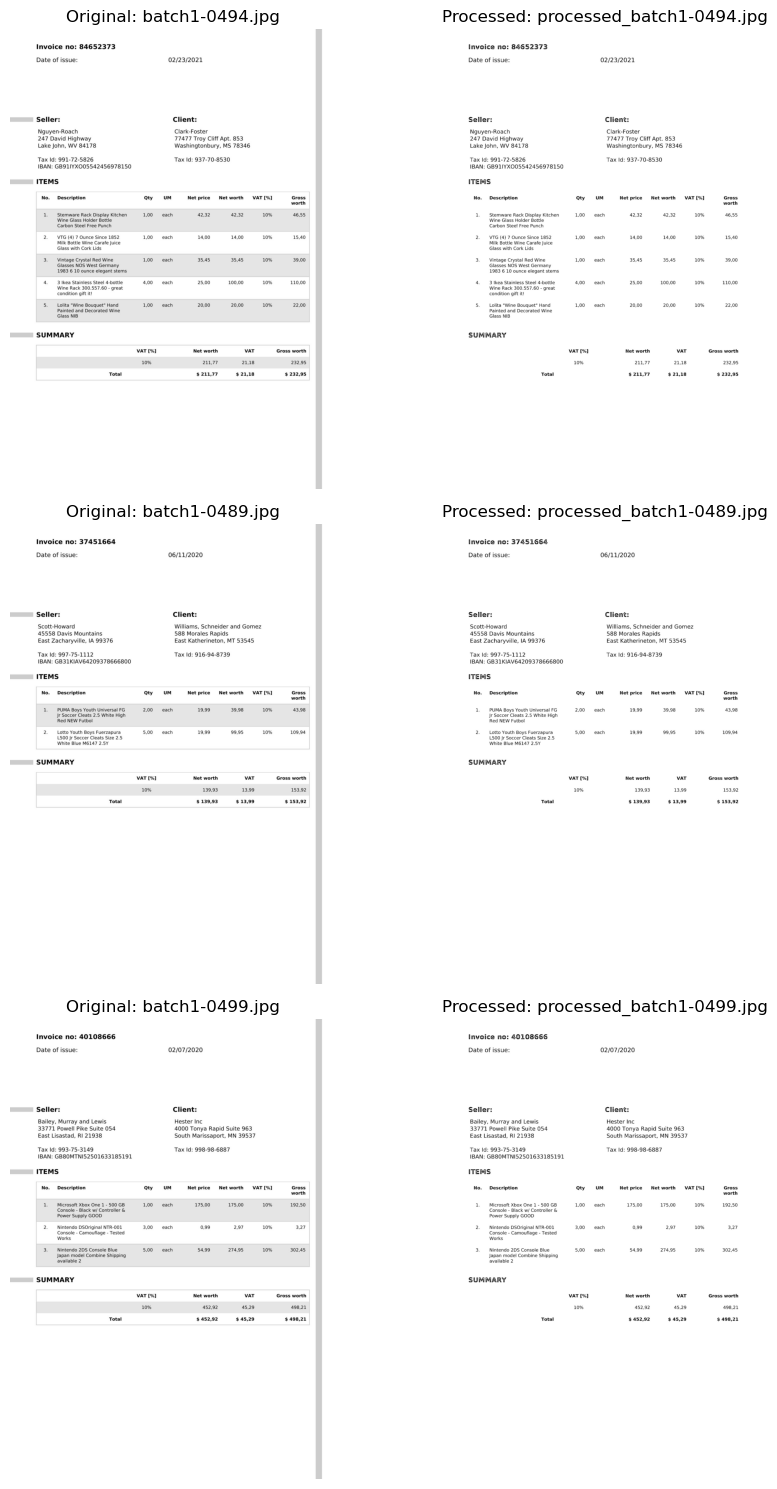

Processed images saved to: ../finalproject_data/processed_images


In [7]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv"
]

# Initialize preprocessor
preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    '../finalproject_data/batch_1/batch1_1',
    '../finalproject_data/batch_1/batch1_2',
    '../finalproject_data/batch_1/batch1_3'
]

# Process all datasets
all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")
    
    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

# Combine all results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")
    
    # Visualize sample results
    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)
    
    print(f"Processed images saved to: {output_image_path}")

In [3]:
# Merge DFs to get processed image file paths
combined_results = pd.read_csv("../finalproject_data/combined_results.csv")
gt_merged_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
gt_merged_df.drop(columns=["File Name", "due_date"], inplace=True)

In [10]:
# Initialize text detector
ocr_text_detector = PytesseractInvoiceTextDetector(output_dir="../finalproject_data/output_images", debug_totals=True)

# Process all of the invoices 
summary_df = ocr_text_detector.process_dataset(combined_results, sample_frac=None)

Processing 1414 images...


Processing OCR batches: 100%|██████████| 142/142 [17:55<00:00,  7.57s/it]


TEXT DETECTION SUMMARY
Total images processed: 1414
Successful extractions: 1414
Failed extractions: 0
Average words per image: 142.9
Average confidence: 93.7%

Extracted invoice fields:
  invoice_number: 1414 images (100.0%)
  invoice_date: 1414 images (100.0%)
  seller_name: 1411 images (99.8%)
  client_name: 1413 images (99.9%)
  tax: 1414 images (100.0%)
  net_worth: 1409 images (99.6%)
  total_amount: 1414 images (100.0%)


In [11]:
train_df, test_df = train_test_split(gt_merged_df, test_size=0.2, random_state=42)

# Produce metrics
metrics_df, overall = ocr_text_detector.evaluate_against_ground_truth(test_df)

print(metrics_df)
print("\nOverall:", overall)

Prediction rows: 1414
Prediction unique keys: 1413
Ground truth rows: 283
Ground truth unique keys: 283
Key overlap: 283
Key overlap: 283
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 283              283      281  0.992933   
1    invoice_date                 283              283      283  1.000000   
2     seller_name                 283              282      280  0.989399   
3     client_name                 283              283      283  1.000000   
4       net_worth                 283              281      274  0.968198   
5    total_amount                 283              283      276  0.975265   
6             tax                 283              283      281  0.992933   

   precision    recall        f1  
0   0.992933  0.992933  0.992933  
1   1.000000  1.000000  1.000000  
2   0.992908  0.989399  0.991150  
3   1.000000  1.000000  1.000000  
4   0.975089  0.968198  0.971631  
5   0.975265  0.975265  0.975265  


In [12]:
# Mismatch-only: tax, net_worth, total_amount (_gt vs _pred), same normalization as evaluation
# Requires: `gt_merged_df` and `ocr_text_detector.full_results` from the Pytesseract cells above.
# from scripts.eval_utils import normalize_money
# import numpy as np
# import pandas as pd

_pred_rows = []
for _r in ocr_text_detector.full_results:
    _row = {"processed_file": _r["filename"]}
    _row.update(_r.get("invoice_fields", {}))
    _pred_rows.append(_row)
_money_pred_df = pd.DataFrame(_pred_rows)

_merge_key = "processed_file"
_money_merged = gt_merged_df.merge(
    _money_pred_df,
    on=_merge_key,
    how="inner",
    suffixes=("_gt", "_pred"),
)

_money_fields = ["tax", "net_worth", "total_amount"]

def _money_norm_series(series):
    return series.apply(normalize_money)

_mismatch_mask = np.zeros(len(_money_merged), dtype=bool)
for _f in _money_fields:
    _gt_n = _money_norm_series(_money_merged[f"{_f}_gt"])
    _pr_n = _money_norm_series(_money_merged[f"{_f}_pred"])
    _valid_gt = _gt_n.notna()
    _valid_pr = _pr_n.notna()
    _correct = (_gt_n == _pr_n) & _valid_gt & _valid_pr
    _mismatch_mask |= ~_correct

_money_mismatch_cols = []
for _f in _money_fields:
    _money_mismatch_cols.extend([f"{_f}_gt", f"{_f}_pred"])

_out_cols = [_merge_key] + _money_mismatch_cols
money_field_mismatches_df = _money_merged.loc[_mismatch_mask, _out_cols].copy()
print(f"Mismatch rows: {len(money_field_mismatches_df)} / inner-join rows: {len(_money_merged)}")
money_field_mismatches_df


Mismatch rows: 47 / inner-join rows: 1416


,processed_file,tax_gt,tax_pred,net_worth_gt,net_worth_pred,total_amount_gt,total_amount_pred
15,processed_batch1-0210.jpg,38.66,38.66,347.94,386.60,386.60,425.26
35,processed_batch1-0167.jpg,8.66,8.66,77.90,86.56,86.56,95.22
41,processed_batch1-0098.jpg,0.20,0.20,1.79,1.99,1.99,2.19
44,processed_batch1-0082.jpg,37.15,37.15,334.36,371.51,371.51,408.66
45,processed_batch1-0114.jpg,0.30,0.30,2.69,2.99,2.99,3.29
56,processed_batch1-0066.jpg,0.20,0.20,1.79,1.99,1.99,2.19
112,processed_batch1-0429.jpg,26.14,26.14,235.27,261.41,261.41,287.55
174,processed_batch1-0449.jpg,1610.11,101.14,16101.14,17711.25,17711.25,17711.25
205,processed_batch1-0176.jpg,5117.76,117.76,51177.59,56295.35,56295.35,56295.35
220,processed_batch1-0064.jpg,491.98,411.82,4919.84,491.98,5411.82,5411.82


In [ ]:
# Debug bottom-line money (tax / net / total): OCR lines, parsed amounts, chosen path.
# Set PF to a `processed_file` from ground truth (e.g. one row where tax/net/total pred was NaN or wrong), then re-run.
import pprint

PF = "processed_batch1-0210.jpg"  # e.g. "processed_batch1-0858.jpg"

if PF is None:
    print("Set PF to a processed_file string from gt_merged_df, then re-run this cell.")
else:
    _path = gt_merged_df.loc[gt_merged_df["processed_file"] == PF, "processed_path"].iloc[0]
    pprint.pp(ocr_text_detector.debug_bottom_totals_for_image(_path))


{'lines': [{'text_preview': 'SUMMARY', 'amounts': []},
           {'text_preview': 'VAT [%] Net worth VAT Gross worth', 'amounts': []},
           {'text_preview': '10% 386,60 38,66 425,26',
            'amounts': [386.6, 38.66, 425.26]},
           {'text_preview': 'Total $ 386,60 $ 38,66 $ 425,26',
            'amounts': [386.6, 38.66, 425.26]}],
 'candidates': [],
 'path': 'summary_row_after_summary_heading',
 'result': {'tax': '38.66', 'net_worth': '386.60', 'total_amount': '425.26'},
 'summary_value_row_index': 2}



Invoice Processing Analysis Dashboard

PROCESSING OVERVIEW
Total images processed: 1,414
Successful extractions: 1,414 (100.0%)
Failed extractions: 0 (0.0%)

FIELD EXTRACTION SUCCESS RATES
  invoice_number : 100.0%
  invoice_date   : 100.0%
  seller_name    :  99.8%
  client_name    :  99.9%
  tax            : 100.0%
  net_worth      :  99.6%
  total_amount   : 100.0%


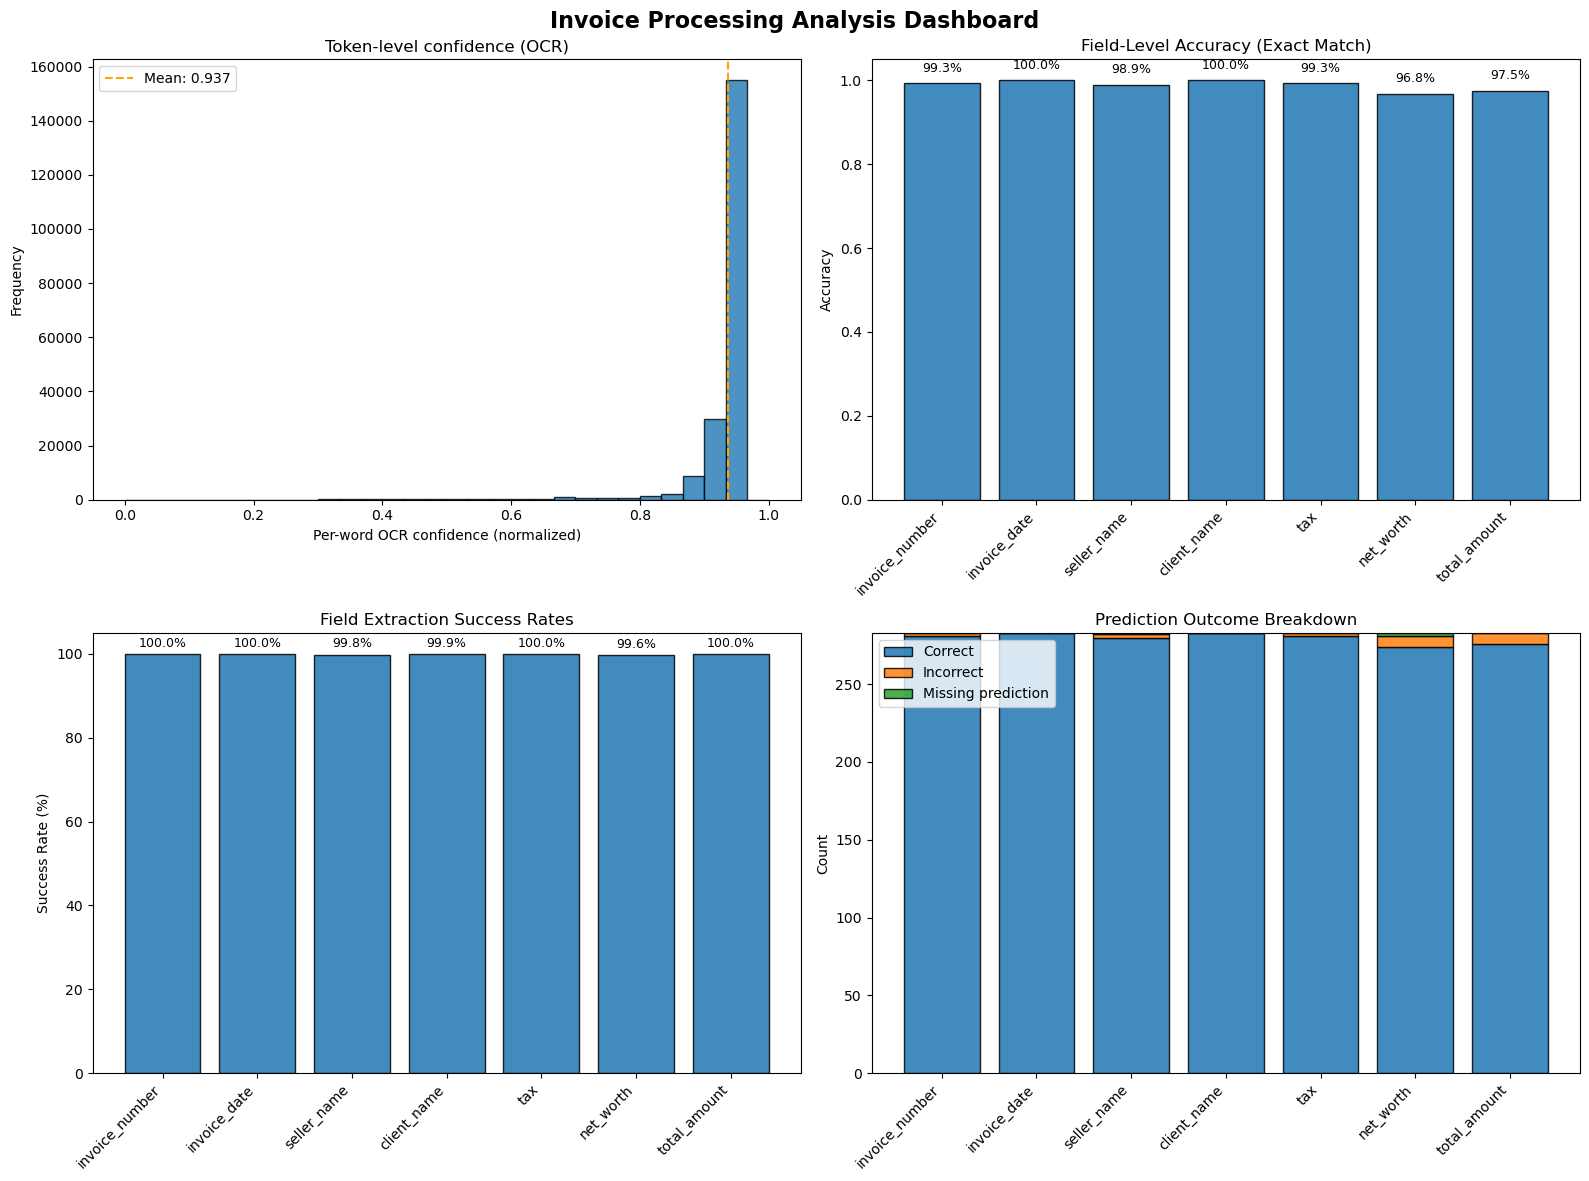


Sample 1: processed_batch1-0494.jpg
Total words detected: 165
Average confidence: 93.958

Extracted Invoice Fields:
  invoice_number: 84652373
  invoice_date: 2021-02-23
  seller_name: Nguyen-Roach
  client_name: Clark-Foster
  tax: 21.18
  net_worth: 211.77
  total_amount: 232.95

Sample extracted text (first 10 words):
  Invoice no: 84652373 Date of issue: 02/23/2021 Seller: Client: Nguyen-Roach...


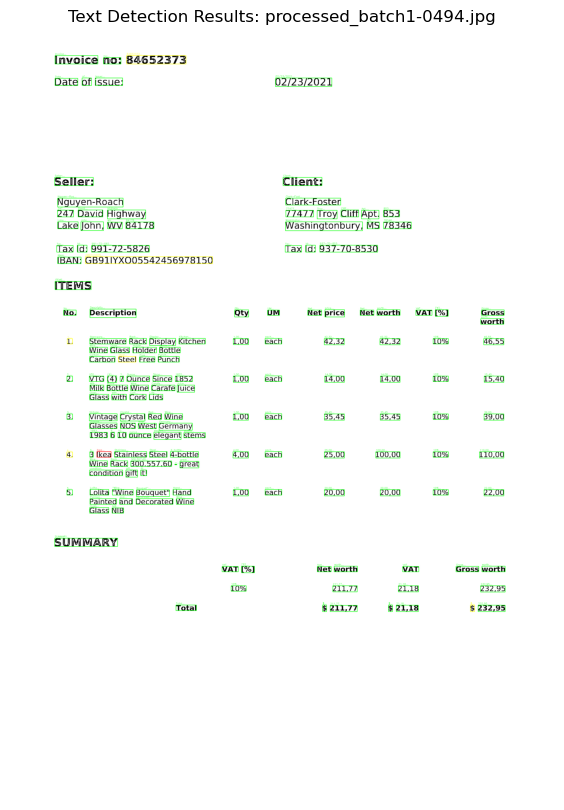


Extracted Invoice Fields:
  invoice_number: 84652373
  invoice_date: 2021-02-23
  seller_name: Nguyen-Roach
  client_name: Clark-Foster
  tax: 21.18
  net_worth: 211.77
  total_amount: 232.95

Sample 2: processed_batch1-0489.jpg
Total words detected: 108
Average confidence: 94.148

Extracted Invoice Fields:
  invoice_number: 37451664
  invoice_date: 2020-06-11
  seller_name: Scott-Howard
  client_name: Williams, Schneider and Gomez
  tax: 13.99
  net_worth: 139.93
  total_amount: 153.92

Sample extracted text (first 10 words):
  Invoice no: 37451664 Date of issue: 06/11/2020 Seller: Client: Scott-Howard...


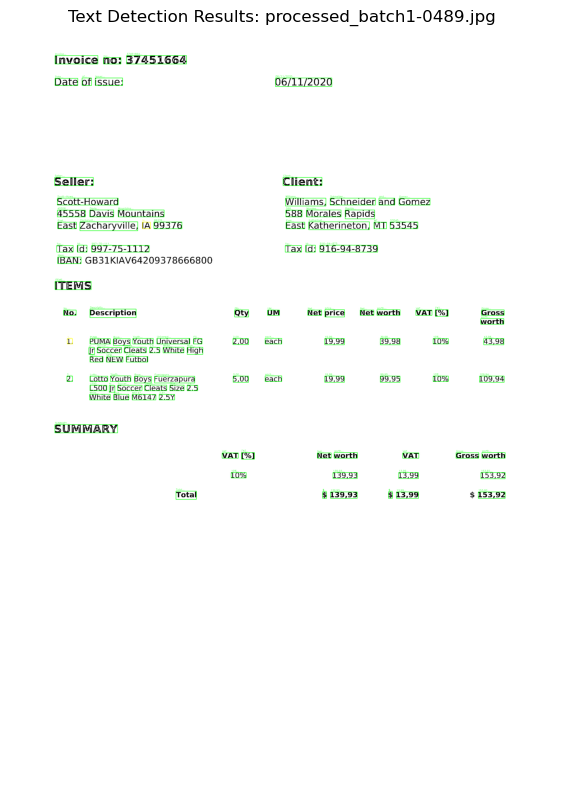


Extracted Invoice Fields:
  invoice_number: 37451664
  invoice_date: 2020-06-11
  seller_name: Scott-Howard
  client_name: Williams, Schneider and Gomez
  tax: 13.99
  net_worth: 139.93
  total_amount: 153.92

Sample 3: processed_batch1-0499.jpg
Total words detected: 129
Average confidence: 93.566

Extracted Invoice Fields:
  invoice_number: 40108666
  invoice_date: 2020-02-07
  seller_name: Bailey, Murray and Lewis
  client_name: Hester Inc
  tax: 45.29
  net_worth: 452.92
  total_amount: 498.21

Sample extracted text (first 10 words):
  Invoice no: 40108666 Date of issue: 02/07/2020 Seller: Client: Bailey,...


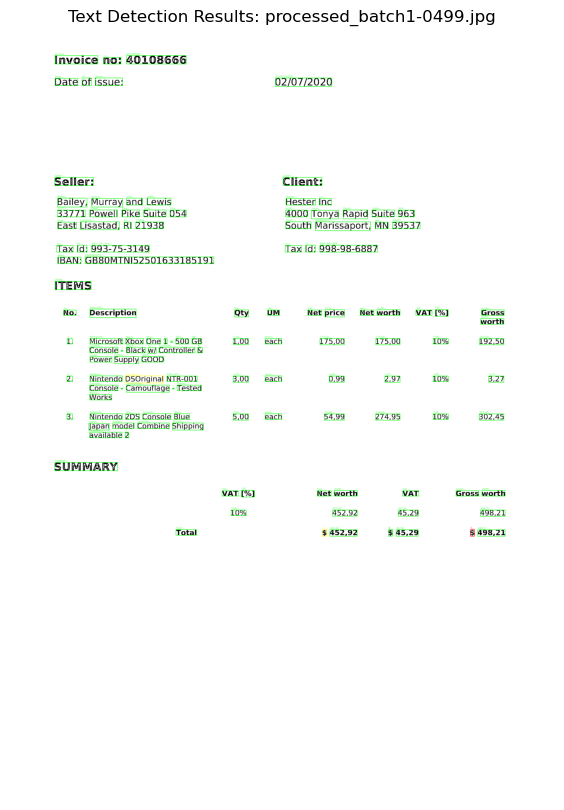


Extracted Invoice Fields:
  invoice_number: 40108666
  invoice_date: 2020-02-07
  seller_name: Bailey, Murray and Lewis
  client_name: Hester Inc
  tax: 45.29
  net_worth: 452.92
  total_amount: 498.21


In [13]:
dashboard_stats = create_analysis_dashboard(
    ocr_text_detector.full_results,
    metrics_df=metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    panel_model="ocr",
)

visualize_sample_results(
    ocr_text_detector.full_results,
    visualize_text_fn=ocr_text_detector.visualize_text_extraction,
    n_samples=3
)

## LayoutLMv3 model (weak supervision)

In [2]:
# Reuse earlier `combined_results` if present; otherwise load from disk
if "combined_results" not in globals():
    combined_results = pd.read_csv("../finalproject_data/combined_results.csv")
if "ground_truth_df" not in globals():
    ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")

# Merge to align GT with processed image paths
if "gt_merged_df" not in globals():
    gt_merged_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
    gt_merged_df = gt_merged_df.drop(columns=["File Name", "due_date"], errors="ignore")

train_df, test_df = train_test_split(gt_merged_df, test_size=0.2, random_state=42)

layoutlm_data_dir = "../finalproject_data/layoutlmv3_data"

In [17]:
gt_merged_df = gt_merged_df.drop(columns=["File Name", "due_date"], errors="ignore")

layoutlm_data_dir = "../finalproject_data/layoutlmv3_data"

builder = LayoutLMv3InvoiceDatasetBuilder(output_dir=layoutlm_data_dir)

examples = builder.build_examples(
    train_df,
    image_col="processed_path",
    key_col="processed_file",
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    max_examples=None,
)

jsonl_path = builder.save_jsonl(examples)
print(f"Built {len(examples)} weak-labeled examples")
print(f"Saved: {jsonl_path}")

Built 1131 weak-labeled examples
Saved: ../finalproject_data/layoutlmv3_data/layoutlmv3_weak_labels.jsonl


In [10]:
# Weak-label diagnostics for seller/client coverage before training
party_fields = ["seller_name", "client_name"]
rows = []

for ex in examples:
    words = ex.get("words", []) or []
    spans = ex.get("matched_spans", {}) or {}
    norm_words = [normalize_text(w) or "" for w in words]

    for field in party_fields:
        span = spans.get(field)
        matched = isinstance(span, list) and len(span) == 2 and span[0] is not None and span[1] is not None

        span_len = 0
        anchor_nearby = False
        if matched:
            s, e = int(span[0]), int(span[1])
            span_len = max(0, e - s)
            anchor = "seller" if field == "seller_name" else "client"
            left = max(0, s - 12)
            anchor_nearby = any((tok == anchor or tok.rstrip(":") == anchor) for tok in norm_words[left:s])

        rows.append({
            "processed_file": ex.get("processed_file"),
            "field": field,
            "matched": bool(matched),
            "span_len": span_len,
            "anchor_nearby": bool(anchor_nearby),
        })

weak_diag_df = pd.DataFrame(rows)

coverage = (
    weak_diag_df
    .groupby("field", as_index=False)
    .agg(
        total=("matched", "size"),
        matched=("matched", "sum"),
        mean_span_len=("span_len", "mean"),
    )
)
coverage["coverage_pct"] = (coverage["matched"] / coverage["total"] * 100).round(2)
coverage["mean_span_len"] = coverage["mean_span_len"].round(2)

display(coverage)

anchor_view = (
    weak_diag_df[weak_diag_df["matched"]]
    .groupby("field", as_index=False)
    .agg(
        matched_rows=("matched", "size"),
        anchor_nearby_count=("anchor_nearby", "sum"),
    )
)
anchor_view["anchor_nearby_pct_of_matched"] = (
    anchor_view["anchor_nearby_count"] / anchor_view["matched_rows"] * 100
).round(2)

display(anchor_view)

# Optional: inspect unmatched examples for manual triage
display(
    weak_diag_df[~weak_diag_df["matched"]]
    .groupby("field")["processed_file"]
    .head(20)
    .reset_index(drop=True)
)


NameError: name 'examples' is not defined

In [19]:
# Train/val split
train_examples, val_examples = train_test_split(examples, test_size=0.2, random_state=42)

layoutlm_output_dir = "../finalproject_data/layoutlmv3_finetuned_model"

layoutlm_detector = LayoutLMv3InvoiceTokenClassifier()
layoutlm_detector.train(
    train_examples=train_examples,
    eval_examples=val_examples,
    output_dir=layoutlm_output_dir,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
)

print(f"Saved LayoutLMv3 model to: {layoutlm_output_dir}")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.bias      | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.weight    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Seqeval F1
50,0.421966,0.147404,0.690347
100,0.100449,0.053013,0.806334
150,0.057186,0.038898,0.851553
200,0.043589,0.029996,0.927582
250,0.032821,0.031034,0.903958
300,0.026259,0.027420,0.946100
350,0.025109,0.023995,0.937558
400,0.028074,0.025685,0.949227
450,0.022573,0.022180,0.936104
500,0.019743,0.022273,0.954037


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved LayoutLMv3 model to: ../finalproject_data/layoutlmv3_finetuned_model


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Runtime: layoutlmv3-name-resolver-2026-04-28-v2
Key overlap: 283
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 283              283      281  0.992933   
1    invoice_date                 283              283      283  1.000000   
2     seller_name                 283              266      239  0.844523   
3     client_name                 283              275      260  0.918728   
4             tax                 283              282      278  0.982332   
5       net_worth                 283              282      275  0.971731   
6    total_amount                 283              283      277  0.978799   

   precision    recall        f1  
0   0.992933  0.992933  0.992933  
1   1.000000  1.000000  1.000000  
2   0.898496  0.844523  0.870674  
3   0.945455  0.918728  0.931900  
4   0.985816  0.982332  0.984071  
5   0.975177  0.971731  0.973451  
6   0.978799  0.978799  0.978799  

Overall: {'accuracy': np.float64(0.95

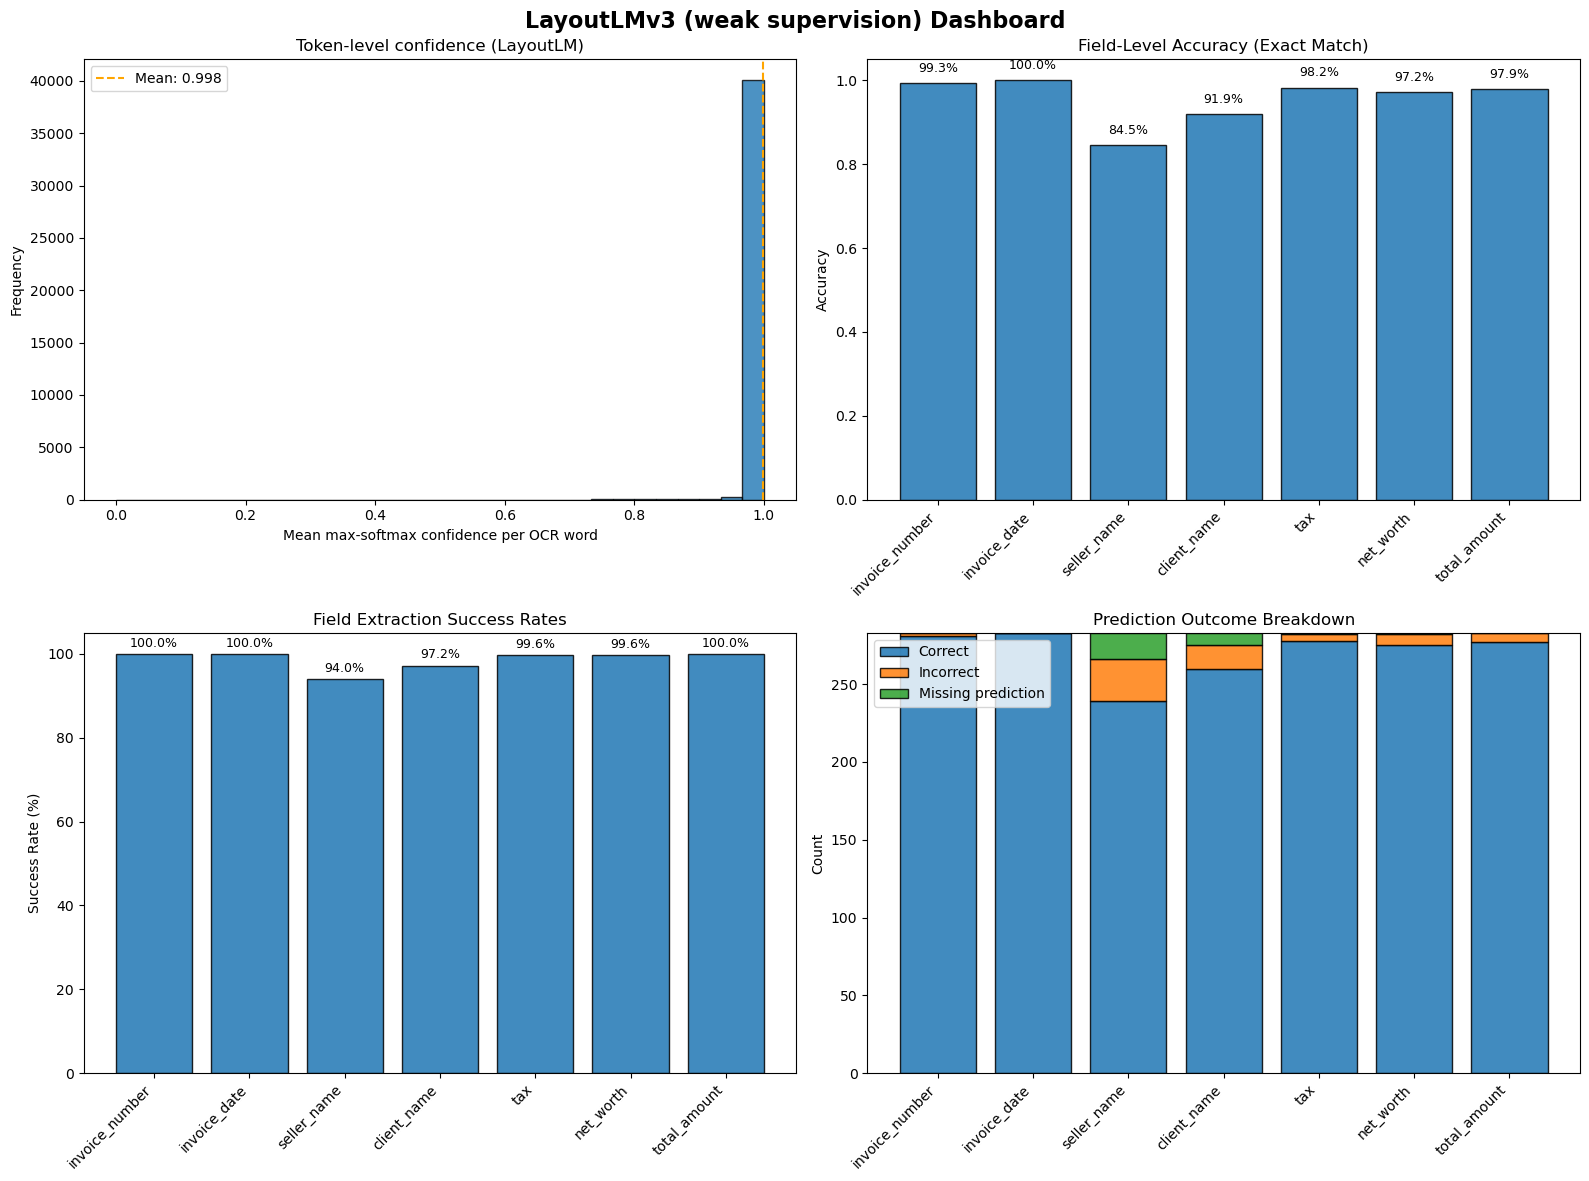


Sample 1: processed_batch1-0858.jpg
Total words detected: 204
Average confidence: N/A

Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  net_worth: 61563.04
  total_amount: 67719.34
  tax: 6156.30
  client_name: Graham-Martinez


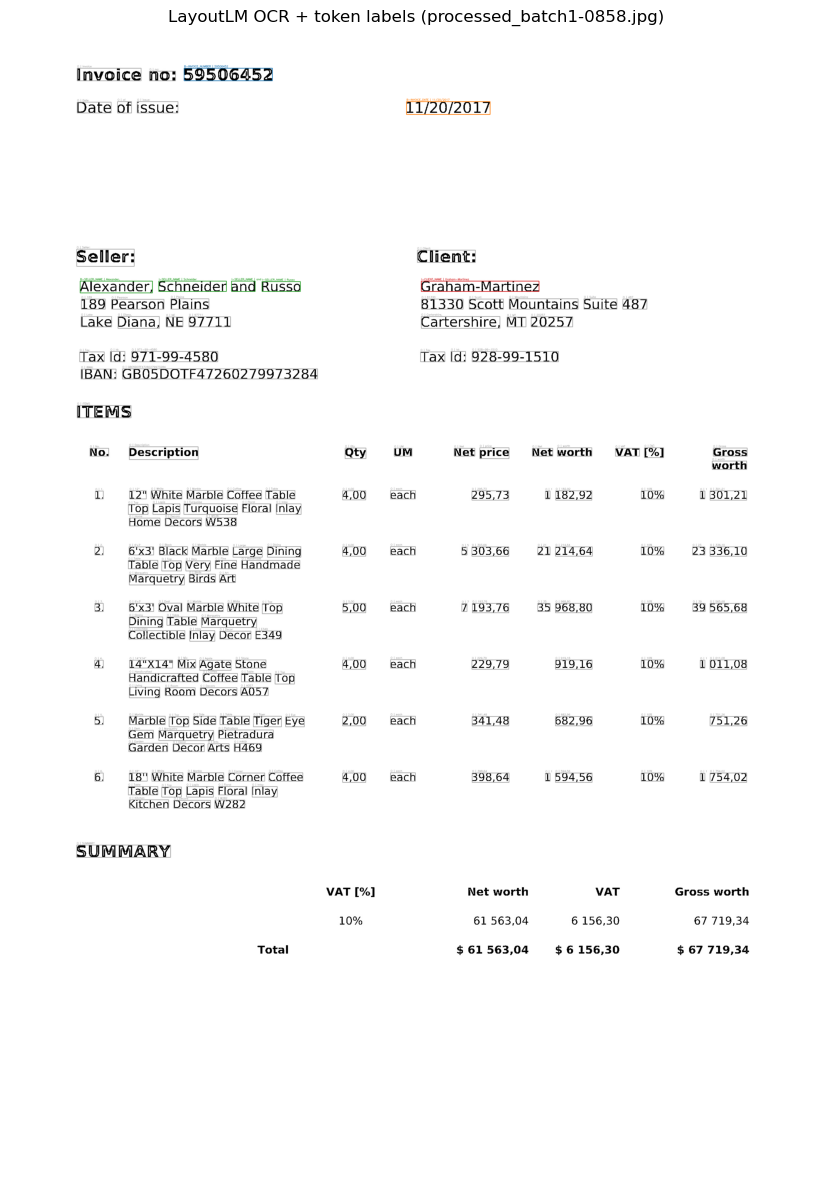


Sample 2: processed_batch1-0935.jpg
Total words detected: 124
Average confidence: N/A

Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  net_worth: 65.42
  total_amount: 71.96
  tax: 6.54
  client_name: Morgan, Farmer and Cook
  seller_name: Johnson, Johnson and Clark


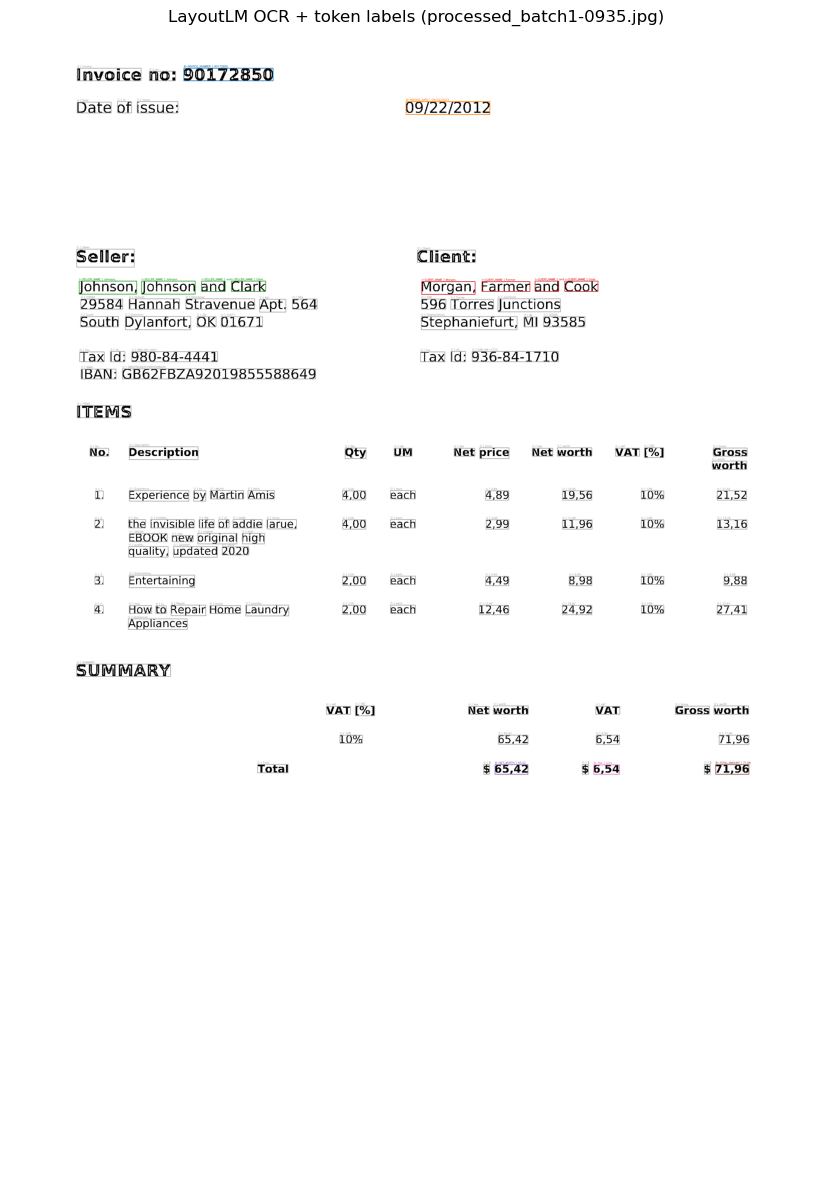

In [18]:
# Inference + evaluation 
import importlib
import scripts.layoutlmv3_model as _layoutlm_mod

importlib.reload(_layoutlm_mod)
from scripts.layoutlmv3_model import LayoutLMv3InvoiceTokenClassifier

layoutlm_output_dir = "../finalproject_data/layoutlmv3_finetuned_model"
layoutlm_detector = LayoutLMv3InvoiceTokenClassifier()
layoutlm_detector.reload_model(layoutlm_output_dir)
layoutlm_detector.enable_seller_anchor_fallback = True
print("Runtime:", layoutlm_detector.runtime_version)  # should show ...-final

layoutlm_pred_df = layoutlm_detector.run_inference(test_df, image_col="processed_path", 
    key_col="processed_file", sample_frac=None, debug_mode=True)

layoutlm_metrics_df, layoutlm_overall = layoutlm_detector.evaluate_against_ground_truth(
    ground_truth_df=test_df,
    pred_df=layoutlm_pred_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    merge_key="processed_file",
)

print(layoutlm_metrics_df)
print("\nOverall:", layoutlm_overall)

_ = create_analysis_dashboard(
    layoutlm_detector.full_results,
    metrics_df=layoutlm_metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    title="LayoutLMv3 (weak supervision) Dashboard",
    panel_model="layoutlm",
)

visualize_sample_results(
    layoutlm_detector.full_results,
    visualize_text_fn=layoutlm_detector.visualize_text_extraction,
    n_samples=2,
    title="LayoutLM sample token-label overlays",
)


In [25]:
from scripts.eval_utils import summarize_field_prediction_gaps  # if needed list fields

gaps = summarize_field_prediction_gaps(
    ground_truth_df=test_df,
    pred_df=layoutlm_pred_df,
    fields=["seller_name", "client_name"],
    merge_key="processed_file",
)
print(gaps)

         field  gt_nonempty  pred_missing_given_gt  mismatch_given_both  \
0  seller_name          283                     17                   27   
1  client_name          283                      8                   15   

                            sample_keys_missing_pred  
0  [processed_batch1-0412.jpg, processed_batch1-0...  
1  [processed_batch1-0865.jpg, processed_batch1-0...  


### LayoutLM single-invoice debug

Run the cell below after `layoutlm_detector` is loaded and `gt_merged_df` exists. Set `DEBUG_FILE` to a `processed_file` value (for example `processed_batch1-0123.jpg`). It prints ground truth vs prediction for seller/client and the full `name_resolution` blob (including `fallback_trace`) so you can see why a field was missing.

In [7]:
# Point this at one row in gt_merged_df["processed_file"], then run.
DEBUG_FILE = "processed_batch1-0123.jpg"

import json
from pathlib import Path

from scripts.eval_utils import normalize_text

assert "layoutlm_detector" in globals(), "Run the LayoutLM load + inference cells first."
assert "gt_merged_df" in globals(), "Build gt_merged_df first."

_row = gt_merged_df.loc[gt_merged_df["processed_file"].astype(str) == DEBUG_FILE]
if _row.empty:
    raise ValueError(
        f"No row for processed_file={DEBUG_FILE!r}. "
        f"Try: gt_merged_df['processed_file'].head() to see valid names."
    )

_image_path = _row["processed_path"].iloc[0]
if not Path(str(_image_path)).exists():
    raise FileNotFoundError(_image_path)

_gt = _row.iloc[0]

# Match your batch eval settings
layoutlm_detector.enable_seller_anchor_fallback = True

_pred_fields, _dbg = layoutlm_detector.predict(
    _image_path,
    fields=DEFAULT_FIELDS,
    return_debug=True,
)

print("processed_file:", DEBUG_FILE)
print("image path:", _image_path)
print()

print("--- Ground truth ---")
print("seller_name:", _gt.get("seller_name"))
print("client_name:", _gt.get("client_name"))
print()

print("--- Model output ---")
print("seller_name:", _pred_fields.get("seller_name"))
print("client_name:", _pred_fields.get("client_name"))
print()

print("--- name_resolution (seller / client) ---")
_nr = _dbg.get("name_resolution") or {}
for _k in ("seller_name", "client_name"):
    print(f"\n### {_k}")
    print(json.dumps(_nr.get(_k), indent=2, default=str))

# OCR sanity: do anchor words appear as tokens?
_words, _wl, _yc, _xc, _wconf = layoutlm_detector._predict_word_labels(image_path=_image_path)
_norm = [normalize_text(w) or "" for w in _words]
print("\n--- Per-word LayoutLM confidence (mean max-softmax over subwords) ---")
print(f"  mean={float(np.mean(_wconf)):.4f}, n_words={len(_wconf)}")
print(f"  mean_x_center={float(np.mean(_xc)):.3f} (0=left, 1=right)")
print("\n--- Anchor token hits (word indices; empty means OCR has no that token) ---")
for _term in ("seller", "vendor", "supplier", "client"):
    _idx = LayoutLMv3InvoiceTokenClassifier._anchor_word_positions(_norm, _term)
    print(f"  {_term}: {_idx[:15]}{' ...' if len(_idx) > 15 else ''}")

print("\n--- First 50 OCR words (index: text) ---")
for _i, _w in enumerate(_words[:50]):
    print(f"  {_i:3d}: {_w!r}")


processed_file: processed_batch1-0123.jpg
image path: ../finalproject_data/processed_images/processed_batch1-0123.jpg

--- Ground truth ---
seller_name: Fernandez-Evans
client_name: Ruiz-Cowan

--- Model output ---
seller_name: Fernandez-Evans
client_name: None

--- name_resolution (seller / client) ---

### seller_name
{
  "source": "anchor_fallback",
  "selected": "Fernandez-Evans",
  "top_candidates": [],
  "fallback_trace": {
    "anchors_tried": [
      {
        "anchor": "seller",
        "min_score": 18.0,
        "seller_boundary_stops": true
      }
    ],
    "raw": "Fernandez-Evans Ruiz-Cowan 374 Mora Parks",
    "compact_strict": "Fernandez-Evans",
    "extraction_tier": {
      "min_score": 18.0,
      "seller_boundary_stops": true
    },
    "extraction_anchor": "seller",
    "sanitized_raw": "Fernandez-Evans",
    "compact_org": null
  }
}

### client_name
{
  "source": "missing",
  "selected": null,
  "top_candidates": [],
  "fallback_trace": {
    "raw": "Guzman Flat 

In [27]:
# Archived debug cell (replaced by consolidated utilities in cells 31-33).



seller_dbg source distribution


,source,count,pct
0,entity,127,44.88
1,anchor_fallback,100,35.34
2,inline_pair_fallback,39,13.78
3,missing,17,6.01



client_dbg source distribution


,source,count,pct
0,anchor_fallback,162,57.24
1,entity,90,31.80
2,inline_pair_fallback,23,8.13
3,missing,8,2.83


In [6]:
# Weak-label name quality diagnostics from matched_spans_meta (before training)
meta_rows = []
for ex in examples:
    pf = ex.get("processed_file")
    meta = ex.get("matched_spans_meta", {}) or {}
    for field in ["seller_name", "client_name"]:
        fm = meta.get(field, {}) or {}
        meta_rows.append({
            "processed_file": pf,
            "field": field,
            "matched": bool(fm.get("matched", False)),
            "quality_ok": bool(fm.get("quality_ok", False)),
        })

name_meta_df = pd.DataFrame(meta_rows)

summary = (
    name_meta_df.groupby("field", as_index=False)
    .agg(
        total=("processed_file", "count"),
        matched=("matched", "sum"),
        quality_ok=("quality_ok", "sum"),
    )
)
summary["matched_pct"] = (summary["matched"] / summary["total"] * 100).round(2)
summary["quality_ok_pct"] = (summary["quality_ok"] / summary["total"] * 100).round(2)
matched_denom = summary["matched"].replace(0, float("nan"))
summary["quality_among_matched_pct"] = ((summary["quality_ok"] / matched_denom) * 100).round(2)

print("Name weak-label quality summary")
display(summary)

print("Sample rows where matched=True but quality_ok=False")
display(
    name_meta_df[(name_meta_df["matched"]) & (~name_meta_df["quality_ok"])].head(30)
)


NameError: name 'examples' is not defined

### Name-source debug utilities (seller/client)

Use the next cell to inspect errors by source (`entity`, `anchor_fallback`, `pair_fallback`, `inline_pair_fallback`, `missing`) for either `seller_name` or `client_name`.

In [32]:
import pandas as pd
from scripts.eval_utils import normalize_text


def _name_source_debug_df(detector, gt_df, field):
    rows = []
    gt_map = gt_df.set_index("processed_file")[field].to_dict()

    for r in (detector.full_results or []):
        pf = r.get("filename")
        pred = (r.get("invoice_fields") or {}).get(field)
        dbg = (r.get("prediction_debug") or {}).get("name_resolution", {}).get(field, {})
        src = dbg.get("source", "unknown")
        gt = gt_map.get(pf)

        pred_n = normalize_text(pred)
        gt_n = normalize_text(gt)

        if gt_n is None:
            status = "no_gt"
        elif pred_n is None:
            status = "missing"
        elif pred_n == gt_n:
            status = "correct"
        else:
            status = "mismatch"

        rows.append(
            {
                "processed_file": pf,
                "field": field,
                "source": src,
                "status": status,
                "pred": pred,
                "gt": gt,
                "prediction_debug": r.get("prediction_debug") or {},
            }
        )

    return pd.DataFrame(rows)


def show_name_source_summary(detector, gt_df):
    dfs = []
    for f in ("seller_name", "client_name"):
        df = _name_source_debug_df(detector, gt_df, f)
        if len(df):
            dfs.append(df)
    all_df = pd.concat(dfs, ignore_index=True)

    summary = (
        all_df.groupby(["field", "source", "status"], dropna=False)
        .size()
        .rename("rows")
        .reset_index()
        .sort_values(["field", "source", "status"])
    )
    display(summary)
    return all_df


def show_name_source_examples(debug_df, field, source, status="mismatch", n=10):
    q = debug_df[
        (debug_df["field"] == field)
        & (debug_df["source"] == source)
        & (debug_df["status"] == status)
    ].copy()
    if q.empty:
        print("No rows for this filter.")
        return q

    keep = ["processed_file", "field", "source", "status", "pred", "gt"]
    display(q[keep].head(n))

    print("\nDetailed debug traces:")
    for _, row in q.head(n).iterrows():
        nr = ((row["prediction_debug"] or {}).get("name_resolution", {}) or {}).get(field, {})
        print("=" * 100)
        print("processed_file:", row["processed_file"])
        print("source:", nr.get("source"))
        print("pred:", row["pred"])
        print("gt:", row["gt"])
        if "fallback_trace" in nr:
            print("fallback_trace:", nr.get("fallback_trace"))
        if "pair_trace" in nr:
            print("pair_trace:", nr.get("pair_trace"))
        if "top_candidates" in nr:
            print("top_candidates:", nr.get("top_candidates"))

    return q


# Example usage after inference:
# name_debug_df = show_name_source_summary(layoutlm_detector, test_df)
# show_name_source_examples(name_debug_df, field="seller_name", source="anchor_fallback", status="mismatch", n=8)
# show_name_source_examples(name_debug_df, field="client_name", source="pair_fallback", status="mismatch", n=8)


In [34]:
# Run this after your inference/eval cell
name_debug_df = show_name_source_summary(layoutlm_detector, test_df)

# Quick drill-downs (edit as needed):
_ = show_name_source_examples(name_debug_df, field="seller_name", source="anchor_fallback", status="mismatch", n=8)
_ = show_name_source_examples(name_debug_df, field="client_name", source="anchor_fallback", status="mismatch", n=8)


,field,source,status,rows
0,client_name,anchor_fallback,correct,147
1,client_name,anchor_fallback,mismatch,15
2,client_name,entity,correct,90
3,client_name,inline_pair_fallback,correct,23
4,client_name,missing,missing,8
5,seller_name,anchor_fallback,correct,74
6,seller_name,anchor_fallback,mismatch,26
7,seller_name,entity,correct,127
8,seller_name,inline_pair_fallback,correct,38
9,seller_name,inline_pair_fallback,mismatch,1


,processed_file,field,source,status,pred,gt
4,processed_batch1-0025.jpg,seller_name,anchor_fallback,mismatch,Smith-Petersen,"Smith, Schaefer and Gonzalez"
19,processed_batch1-1446.jpg,seller_name,anchor_fallback,mismatch,Rodriguez-Stevens,"Chapman, Kim and Green"
21,processed_batch1-0979.jpg,seller_name,anchor_fallback,mismatch,Goodman-Rangel,"Terry, Forbes and Franklin"
25,processed_batch1-0899.jpg,seller_name,anchor_fallback,mismatch,Alexander Roads,Rios-Ramirez
36,processed_batch1-0473.jpg,seller_name,anchor_fallback,mismatch,Williams-Jimenez,"Rose, Smith and Moreno"
38,processed_batch1-1269.jpg,seller_name,anchor_fallback,mismatch,Villanueva-White,"May, Jones and Diaz"
56,processed_batch1-1085.jpg,seller_name,anchor_fallback,mismatch,Stewart Daniel,"Rowe, Payne and Stewart"
70,processed_batch1-0993.jpg,seller_name,anchor_fallback,mismatch,Rogers-Jones,"Mercado, Fields and Lewis"



Detailed debug traces:
processed_file: processed_batch1-0025.jpg
source: anchor_fallback
pred: Smith-Petersen
gt: Smith, Schaefer and Gonzalez
fallback_trace: {'anchors_tried': [{'anchor': 'seller', 'min_score': 18.0, 'seller_boundary_stops': True}], 'raw': 'Gonzalez Smith-Petersen', 'compact_strict': 'Smith-Petersen', 'extraction_tier': {'min_score': 18.0, 'seller_boundary_stops': True}, 'extraction_anchor': 'seller', 'sanitized_raw': 'Smith-Petersen', 'compact_org': None}
top_candidates: []
processed_file: processed_batch1-1446.jpg
source: anchor_fallback
pred: Rodriguez-Stevens
gt: Chapman, Kim and Green
fallback_trace: {'anchors_tried': [{'anchor': 'seller', 'min_score': 18.0, 'seller_boundary_stops': True}], 'raw': 'Green Rodriguez-Stevens 64731 James Branch', 'compact_strict': 'Rodriguez-Stevens', 'extraction_tier': {'min_score': 18.0, 'seller_boundary_stops': True}, 'extraction_anchor': 'seller', 'sanitized_raw': 'Rodriguez-Stevens', 'compact_org': None}
top_candidates: []
proc

,processed_file,field,source,status,pred,gt
290,processed_batch1-0260.jpg,client_name,anchor_fallback,mismatch,USNS Griffin,Mcclain PLC
291,processed_batch1-1100.jpg,client_name,anchor_fallback,mismatch,"Bautistafurt, FL",Hobbs Group
306,processed_batch1-0192.jpg,client_name,anchor_fallback,mismatch,Scott Garden,Browning Ltd
307,processed_batch1-0355.jpg,client_name,anchor_fallback,mismatch,Reed Greens,Moyer-Jones
332,processed_batch1-1383.jpg,client_name,anchor_fallback,mismatch,Martin Curve,Daniels-Farrell
345,processed_batch1-1226.jpg,client_name,anchor_fallback,mismatch,Davis Extensions,Harrison-Davis
346,processed_batch1-0552.jpg,client_name,anchor_fallback,mismatch,"Wellsside, KY",Hall-Cole
406,processed_batch1-1150.jpg,client_name,anchor_fallback,mismatch,Willie Ranch,Casey-Osborn



Detailed debug traces:
processed_file: processed_batch1-0260.jpg
source: anchor_fallback
pred: USNS Griffin
gt: Mcclain PLC
fallback_trace: {'raw': 'Mcclain PLC USNS Griffin', 'tiers_tried': [{'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}], 'picked_tier': {'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}, 'compact_strict': None, 'compact_loose': 'USNS Griffin'}
top_candidates: []
processed_file: processed_batch1-1100.jpg
source: anchor_fallback
pred: Bautistafurt, FL
gt: Hobbs Group
fallback_trace: {'raw': 'Darlene Fork Bautistafurt, FL 80497 Lake Kennethmouth,', 'tiers_tried': [{'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}], 'picked_tier': {'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}, 'compact_strict': None, 'compact_loose': 'Bautistafurt, FL'}
top_candidates: []
processed_file: processed_batch1-0192.jpg
source: anchor_fallback
pred: Scott Garden
gt: Browning Ltd
fallback_trace

## Final Model Notes / Limitations / Future Work

### Final Notes
- **Final LayoutLMv3 configuration** uses weakly supervised token classification with inference-time name-resolution heuristics (entity-first, then guarded fallback).
- **Held-out test performance** is strongest so far for name fields (`seller_name` ~84%, `client_name` ~92% in latest run).
- **Observed source mix** indicates entity predictions are reliable when present, while anchor fallback contributes substantial recall.
- **Reproducibility**: inference cell force-reloads `scripts.layoutlmv3_model` and prints `runtime_version` so notebook runs use the intended code version.

### Current Limitations
- **Residual seller mismatches** are mostly hard edge cases where fallback chooses nearby but wrong party-like strings (e.g., alternate hyphenated names or address-adjacent tokens).
- **OCR dependency** remains high: when OCR token order/segmentation is poor, both entity and fallback quality degrade.
- **Heuristic sensitivity**: fallback behavior can shift with small threshold/token-list changes, so gains on one subset may not transfer uniformly.
- **Weak-label noise** in training still constrains entity-share growth for name fields.

### Future Work
- **Improve weak supervision quality** for seller/client spans (coverage + precision) before adding more inference heuristics.
- **Add confidence-calibrated fallback acceptance** (jointly using model token confidence + heuristic score).
- **Introduce small curated validation set** for heuristic tuning to reduce overfitting to ad-hoc mismatch examples.
- **Consider sequence-level reranker** for seller/client candidates (lightweight classifier) as a replacement for hand-tuned rules.
- **Expand OCR robustness** (alternate OCR engines / consensus OCR) for low-quality documents.